# Actividad Whitepapers

**Autora:** Natalia Andrzejewski  
**Asignatura:** 01MIAR_04_A_2026-27 — Python para la Inteligencia Artificial

## 0. Motivación de la selección

Mi marido padece tinnitus crónico desde hace años: un pitido constante que afecta su concentración, su sueño y su calidad de vida. Esta condición afecta a una proporción muy elevada de la población adulta; la revisión sistemática de Haider et al. (2022) publicada en JAMA Neurology sitúa la prevalencia global del tinnitus en torno al 14% en adultos, lo que equivale a cientos de millones de personas en todo el mundo.

Sin embargo, dado que cada caso de tinnitus presenta una combinación distinta de factores clínicos, auditivos y psicológicos, resulta difícil plantear una solución universal que funcione para todos los pacientes. En este contexto, el aprendizaje automático ofrece una vía prometedora para apoyar la personalización del tratamiento, especialmente en estrategias de sonoterapia y enmascaramiento acústico.

El artículo de Luo et al. (2025) es el que más directamente se relaciona con mi trabajo de investigación, ya que estoy desarrollando una aplicación, MyTinnitusMask, orientada a personalizar el enmascaramiento acústico del tinnitus. La pregunta central de esa app —qué tipo de sonido podría funcionar mejor para un usuario concreto antes incluso de que lo pruebe— coincide con el objetivo general de ese tipo de estudios clínicos: anticipar la respuesta terapéutica a partir de variables recogidas en la evaluación inicial.

Desde un punto de vista aplicado, este enfoque tiene dos implicaciones relevantes:

- Permite explorar cómo un problema clínico real puede formularse como un problema de clasificación supervisada.

- Facilita traducir variables clínicas y psicométricas en un pipeline reproducible de Python para predicción y análisis de importancia de características.

Para la implementación en Python se emplea el dataset público de Mendeley de Ibarra-Zarate et al. (2022), que recoge información clínica, psicométrica y electroencefalográfica de pacientes con tinnitus sometidos a distintas terapias acústicas. Aunque este conjunto de datos no es idéntico al empleado en el artículo principal, sí permite construir un caso de estudio cercano y metodológicamente útil para analizar respuesta terapéutica mediante machine learning.

Lo que quiero aprender: cómo traducir un problema clínico real en un pipeline completo de ML en Python: desde la carga y exploración de datos clínicos hasta la comparación de clasificadores y la interpretación de la importancia de variables.

## 1. Artículo Principal

**Referencia (APA 7ª edición):**

> Luo, G., Lin, Q., Lin, C., & Wu, H. (2025). An innovative predictive model for assessing tinnitus sound therapy outcomes: integrating audiological and psychometric variables. Frontiers in Neurology, 16, 1727373. https://doi.org/10.3389/fneur.2025.1727373

### Resumen del artículo

**Objetivo.** Desarrollar un modelo predictivo capaz de estimar, antes de iniciar el tratamiento, qué pacientes con tinnitus crónico responderán a una intervención basada en sonoterapia. La identificación temprana de pacientes con menor probabilidad de respuesta puede ayudar a personalizar el tratamiento y evitar intervenciones poco eficaces.

**Metodología.**  El estudio propone un enfoque de aprendizaje automático con variables clínicas y psicométricas recogidas en la evaluación basal. Se comparan varios clasificadores habituales en problemas biomédicos, entre ellos regresión logística, random forest, support vector machine, k-nearest neighbors y gradient boosting. Las variables de entrada incluyen dimensiones relacionadas con la severidad del tinnitus, el malestar funcional, la ansiedad y otros factores clínicos relevantes.

**Resultados.** El modelo random forest muestra el mejor rendimiento global dentro del conjunto de métodos evaluados, con una capacidad discriminativa alta según la métrica AUC-ROC. Los autores destacan que ciertas variables clínicas basales parecen tener un peso especialmente importante en la predicción de la respuesta terapéutica.

| Modelo | AUC validación |
|--------|----------------|
| Random Forest | **0,870** |
| K-Nearest Neighbors | 0,812 |
| Gradient Boosting | 0,807 |
| SVM | 0,801 |
| Regresión Logística | — |

**Conclusión.** El estudio sugiere que, a partir de información clínica de rutina, es posible construir modelos útiles para estratificar pacientes y apoyar la toma de decisiones en contextos de sonoterapia. Esto resulta especialmente interesante para el desarrollo de aplicaciones digitales orientadas a terapia personalizada.

**Observación metodológica**
Aunque el estudio constituye una referencia muy útil para inspirar el diseño del pipeline, conviene interpretar con prudencia la transferencia directa de sus resultados a otros datasets. La equivalencia entre variables de distintos cuestionarios no siempre es exacta, y las diferencias en tamaño muestral, definición del objetivo y estructura de los datos pueden afectar al rendimiento del modelo.

### Artículo Complementario

Para llevar la idea a una implementación en Python, se utiliza el dataset abierto de Mendeley publicado por Ibarra-Zarate et al. (2022): Acoustic Therapies for Tinnitus Treatment: An EEG Database. Este conjunto de datos incluye pacientes con tinnitus tratados mediante distintas terapias acústicas, con información clínica, psicométrica y electroencefalográfica.

Este dataset es especialmente útil para el ejercicio porque permite:
- Trabajar con datos clínicos reales.
- Construir una variable objetivo de respuesta terapéutica.
- Comparar modelos de clasificación en un contexto biomédico.
- Analizar la importancia relativa de variables predictoras.

Referencia (APA 7ª edición):
> Ibarra-Zarate, D. I., Alonso-Valerdi, L. M., Cuevas-Romero, A. R., & Intriago-Campos, L. A. (2022). Acoustic therapies for tinnitus treatment: An EEG database. Mendeley Data, Version 2. https://doi.org/10.17632/kj443jc4yc.2

## 2. Implementación en Python

El análisis reproduce de forma aproximada el enfoque de un problema de predicción de respuesta a sonoterapia aplicado de Luo et al. (2025), al dataset público de Mendeley. El pipeline completo se divide en cuatro fases:

1. **Carga y exploración de datos**: descripción del dataset, distribuciones clínicas, balance de clases.
2. **Ingeniería de características**: construcción de variables predictoras útiles para el modelo.
3. **Comparación de clasificadores**: random forest, regresión logística y SVM mediante validación cruzada estratificada.
4. **Importancia de variables** : identificación de los factores más influyentes con random forest.

**Nota sobre los datos:** el dataset se encuentra en formato Excel y contiene tanto variables clínicas como psicométricas. Para este ejercicio, el archivo se encuentra descargado y situado en la misma carpeta de este notebook.

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
sns.set_style("whitegrid")

print("Librerías cargadas.")

Librerías cargadas.


### 2.1 Carga de datos

Se carga el archivo Excel del dataset de Mendeley. En caso de encontrar valores ausentes, se aplican técnicas de limpieza y preparación antes del modelado. Algunas columnas del archivo deben renombrarse para facilitar su lectura y uso posterior.

En esta fase, el objetivo no es todavía entrenar ningún modelo, sino asegurar que las variables relevantes queden correctamente identificadas y que los datos se encuentren en un formato homogéneo.

In [47]:
datasetExcel = "./Tinnitus_Database.xlsx"

therapy_groups = {
    1: "Placebo (música)",
    2: "TRT (Tinnitus Retraining)",
    3: "TEAE (Enriquecimiento Acústico)",
    4: "TBB (Binaural Beats)",
    5: "ADT (Discriminación Auditiva)",
}

raw = pd.read_excel(datasetExcel)
raw = raw.iloc[1:].reset_index(drop=True)  # fila 0 son sub-encabezados
raw = raw.rename(columns={"Unnamed: 7": "Tinnitus_Freq", "Unnamed: 8": "Tinnitus_dB", "Unnamed: 21": "THI_S3", "Unnamed: 22": "THI_S4"})
raw.replace("-", np.nan, inplace=True)

n_total = len(raw)
raw = raw[raw["Group"].isin([1, 2, 3, 4, 5])].copy()  # excluir grupo 6 = controles sanos

col_map = {
    "Group": "therapy_group", "Age": "age_cat",
    "HL-D": "HL_D", "HL-I": "HL_I",
    "HAD-A S2": "HADS_A", "HAD-S S2": "HADS_D",
    "THI": "THI_S2", "THI Effect": "THI_effect",
    "Tinnitus_Freq": "tinnitus_freq", "Tinnitus_dB": "tinnitus_db",
}
df_all = raw[list(col_map.keys()) + ["Sex", "TINNITUS"]].rename(columns=col_map).copy()
df_all["sex"] = df_all["Sex"].map({"F": 0, "M": 1})
df_all["laterality"] = df_all["TINNITUS"].map({"L": 0, "R": 1, "B": 2})
df_all = df_all.drop(columns=["Sex", "TINNITUS"])

for col in df_all.columns:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

n_dropouts = df_all["THI_effect"].isna().sum()
df = df_all.dropna(subset=["THI_effect"]).reset_index(drop=True)
data_source = "Ibarra-Zarate et al. (2022), datos reales"

df["responder"] = (df["THI_effect"] >= 1).astype(int)
df_all["responder"] = (df_all["THI_effect"] >= 1).where(df_all["THI_effect"].notna()).astype("Int64")

print(f"Dataset completo: {n_total} participantes")
print(f"  → Pacientes con tinnitus (grupos 1–5): {len(df_all)}")
print(f"  → Controles sanos (grupo 6, excluidos): {n_total - len(df_all)}")
print(f"  → Abandonos sin resultado: {n_dropouts}")
print(f"  → Pacientes para ML: {len(df)}")
print(f"\nRespondedores: {df.responder.sum()} / {len(df)} ({df.responder.mean()*100:.1f} %)")
display(df.head(5))

Dataset completo: 103 participantes
  → Pacientes con tinnitus (grupos 1–5): 89
  → Controles sanos (grupo 6, excluidos): 14
  → Abandonos sin resultado: 19
  → Pacientes para ML: 70

Respondedores: 25 / 70 (35.7 %)


,therapy_group,age_cat,HL_D,HL_I,HADS_A,HADS_D,THI_S2,THI_effect,tinnitus_freq,tinnitus_db,sex,laterality,responder
0,1.0,2,22.0,29.0,1.0,1.0,2.0,0.0,3000,50.0,0,0,0
1,1.0,3,19.0,29.0,1.0,2.0,1.0,1.0,6000,50.0,0,0,1
2,1.0,2,14.0,16.0,1.0,1.0,2.0,1.0,6000,20.0,0,1,1
3,1.0,2,10.0,12.0,1.0,1.0,3.0,0.0,8000,50.0,1,2,0
4,1.0,3,17.0,15.0,2.0,1.0,3.0,0.0,6000,30.0,0,0,0


### 2.2 Exploración de datos

Antes de entrenar cualquier modelo es fundamental comprender la estructura de los datos. En esta etapa se analizan tres aspectos:

- Balance de clases, para comprobar si la variable objetivo está equilibrada.
- Distribución de las variables clínicas principales, para detectar rangos, asimetrías y posibles valores atípicos.
- Relación entre variables, para identificar correlaciones y redundancias.

Este análisis exploratorio es importante porque, en datasets clínicos pequeños, las decisiones de preprocesamiento pueden influir de manera notable en los resultados finales.

**Glosario de variables del dataset:**

| Variable | Nombre completo | Escala |
|---|---|---|
| `THI_S2` | *Tinnitus Handicap Inventory* — sesión 2 (basal) | 1 = leve · 2 = moderado · 3 = severo · 4 = catastrófico |
| `HADS_A` | *Hospital Anxiety and Depression Scale* — subescala ansiedad | 1 = normal · 2 = borderline · 3 = anormal |
| `HADS_D` | *Hospital Anxiety and Depression Scale* — subescala depresión | 1 = normal · 2 = borderline · 3 = anormal |
| `HL_D` | *Hearing Loss* oído derecho (*Derecho*) | dB (pérdida auditiva) |
| `HL_I` | *Hearing Loss* oído izquierdo (*Izquierdo*) | dB (pérdida auditiva) |
| `THI_effect` | Efecto del tratamiento sobre el THI | 0 = sin cambio · 1 = mejora leve · 2 = mejora notable |

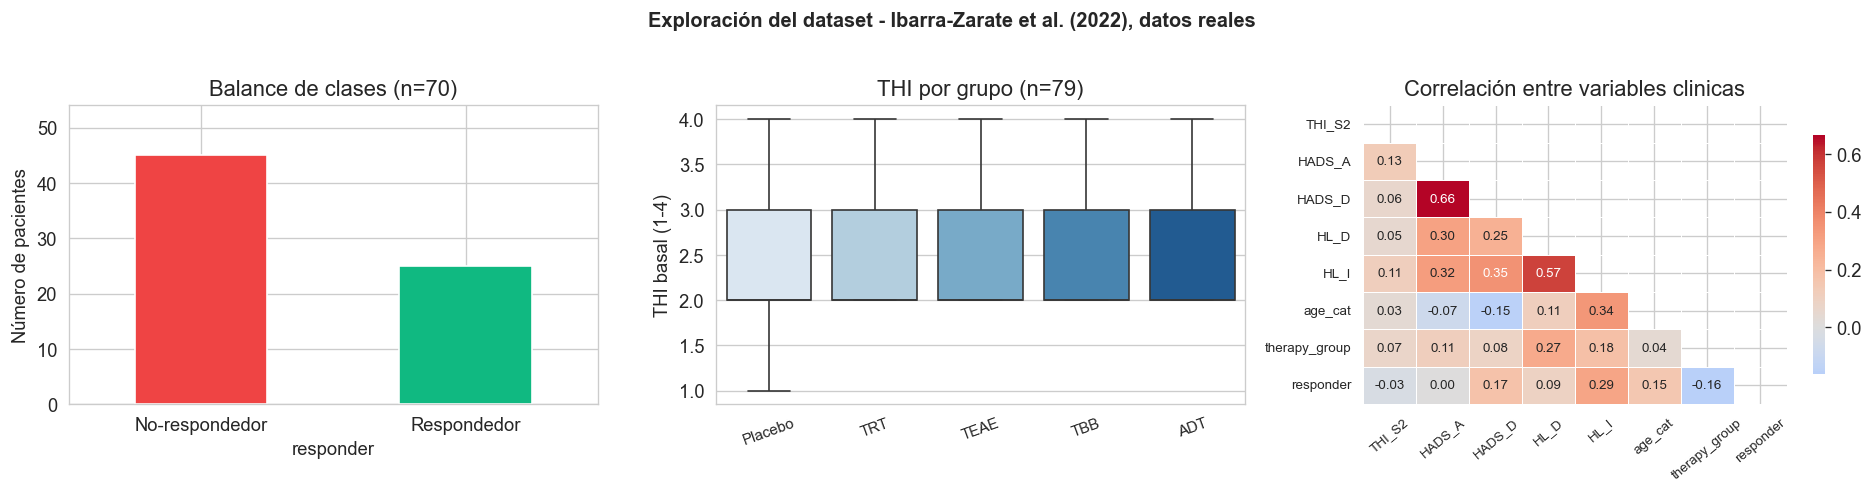


Estadísticas descriptivas (89 pacientes con tinnitus):


,THI_S2,HADS_A,HADS_D,HL_D,HL_I
count,79.00,80.00,80.00,89.00,88.00
mean,2.48,1.27,1.36,24.00,26.64
std,0.68,0.59,0.68,14.84,15.73
min,1.00,1.00,1.00,5.00,8.00
25%,2.00,1.00,1.00,15.00,15.00
50%,2.00,1.00,1.00,20.00,24.00
75%,3.00,1.00,1.25,29.00,30.00
max,4.00,3.00,3.00,96.00,92.00


In [48]:
fig, plots = plt.subplots(1, 3, figsize=(16, 4))

# balance de clases
(df["responder"].map({0: "No-respondedor", 1: "Respondedor"})
                .value_counts().sort_index()
                .plot(kind="bar", ax=plots[0], color=["#EF4444", "#10B981"],
                      edgecolor="white", width=0.5, rot=0))
plots[0].set(ylabel="Número de pacientes", title=f"Balance de clases (n={len(df)})")
plots[0].set_ylim(0, df["responder"].value_counts().max() * 1.20)

# THI basal por grupo
df_eda = df_all.dropna(subset=["THI_S2"]).copy()
df_eda["grupo"] = df_eda["therapy_group"].map({k: v.split("(")[0].strip() for k, v in therapy_groups.items()})
sns.boxplot(data=df_eda, x="grupo", y="THI_S2", palette="Blues", ax=plots[1])
plots[1].set(xlabel="", ylabel="THI basal (1-4)", title=f"THI por grupo (n={len(df_eda)})")
plots[1].tick_params(axis="x", rotation=20, labelsize=9)

# correlación entre variables
num_cols = ["THI_S2", "HADS_A", "HADS_D", "HL_D", "HL_I", "age_cat", "therapy_group", "responder"]
corr = df[num_cols].dropna().corr()
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), ax=plots[2],
            cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 8}, linewidths=0.4, cbar_kws={"shrink": 0.8})
plots[2].set(title="Correlación entre variables clinicas")
plots[2].tick_params(axis="x", rotation=40, labelsize=8)
plots[2].tick_params(axis="y", labelsize=8)

plt.suptitle(f"Exploración del dataset - {data_source}", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nEstadísticas descriptivas (89 pacientes con tinnitus):")
display(df_all[["THI_S2", "HADS_A", "HADS_D", "HL_D", "HL_I"]].describe().round(2))

### 2.3 Ingeniería de características

A partir de las variables disponibles en el dataset se construyen predictores útiles para el problema de clasificación. El objetivo es transformar información clínica heterogénea en un conjunto de variables numéricas que el modelo pueda interpretar.

Por ejemplo, pueden derivarse características como:

- la media de la pérdida auditiva entre ambos oídos,
- la asimetría entre oído derecho e izquierdo,
- la categoría terapéutica asignada,
- la categoría de edad,
- y las escalas clínicas y psicométricas disponibles.

**Consideración importante**

En este trabajo, algunas variables del dataset de Mendeley se utilizan como aproximaciones funcionales de dimensiones clínicas presentes en el estudio de referencia. No se trata de equivalencias exactas entre cuestionarios, sino de variables que capturan constructos similares, como severidad, malestar emocional o perfil audiológico.

Esto es relevante porque mejora la claridad metodológica y evita presentar como idénticas escalas que, en realidad, solo son comparables de forma parcial.

Se construyen las características predictoras equivalentes a las empleadas por Luo et al. (2025). El dataset de Mendeley usa escalas ordinales (THI en 4 categorías, HADS en 3 niveles) en lugar de puntuaciones continuas, pero captura las mismas dimensiones clínicas.

| Característica | Variable en el dataset | Equivalente en Luo et al. (2025) |
|---|---|---|
| `THI_S2` | Categoría THI en sesión 2 (1–4) | TFI basal — severidad funcional |
| `HADS_A` | Ansiedad en sesión 2 (1–3) | GAD-7 |
| `HADS_D` | Depresión en sesión 2 (1–3) | Componente de TAQ |
| `HL_avg` | Media pérdida auditiva ambos oídos (dB) | Nivel de disconfort auditivo |
| `HL_asym` | Asimetría de pérdida entre oídos (dB) | Perfil audiológico |
| `therapy_group` | Tipo de terapia asignada (1–5) | Historia de tratamientos previos |
| `age_cat` | Categoría de edad (1=joven, 2=adulto, 3=mayor) | Variable demográfica |

2.3.1 Tratamiento de valores ausentes

Los modelos de machine learning no pueden trabajar directamente con celdas vacías. Por ello, se aplica imputación simple mediante la mediana de cada variable numérica.

Esta estrategia es razonable en un dataset pequeño y clínico, ya que:

- preserva el tamaño muestral,
- reduce la pérdida de información,
- y evita introducir valores extremos artificiales.

No obstante, en un estudio más amplio podrían evaluarse métodos más sofisticados de imputación, especialmente si los valores ausentes no fueran aleatorios.

In [49]:
df["HL_avg"]  = df[["HL_D", "HL_I"]].mean(axis=1)
df["HL_asym"] = (df["HL_D"] - df["HL_I"]).abs()

features = ["THI_S2", "HADS_A", "HADS_D", "HL_avg", "HL_asym", "therapy_group", "age_cat"]

df_model = df[features + ["responder"]].copy()
for col in features:
    df_model[col] = df_model[col].fillna(df_model[col].median())

X = df_model[features].values
y = df_model["responder"].values

print(f"Features: {X.shape}  →  {len(features)} variables, {len(y)} pacientes")
print(f"Balance: {y.sum()} respondedores ({y.mean()*100:.1f}%)  |  {(y==0).sum()} no-respondedores")

print("\nMedias por grupo de respuesta:")
display(df_model.groupby("responder")[["THI_S2", "HADS_A", "HADS_D", "HL_avg"]].mean().round(2).rename(
    index={0: "No-respondedor", 1: "Respondedor"}))

Features: (70, 7)  →  7 variables, 70 pacientes
Balance: 25 respondedores (35.7%)  |  45 no-respondedores

Medias por grupo de respuesta:


,THI_S2,HADS_A,HADS_D,HL_avg
responder,,,,
No-respondedor,2.44,1.2,1.22,22.70
Respondedor,2.40,1.2,1.44,28.28


### 2.4 Comparación de modelos de clasificación

Se evalúan tres clasificadores habituales en problemas biomédicos:

- Regresión logística
- Random forest
- SVM

La comparación se realiza mediante validación cruzada estratificada de 5 folds, lo que permite mantener la proporción de clases en cada partición y obtener una estimación más estable del rendimiento.

La métrica principal es el AUC-ROC, ya que mide la capacidad del modelo para discriminar entre respondedores y no respondedores sin depender de un umbral concreto de decisión. Esto resulta especialmente útil en datasets pequeños y potencialmente desbalanceados.

**Observación metodológica**

El escalado de variables se realiza dentro del pipeline de validación cruzada para evitar data leakage. Esta decisión es importante porque impide que las estadísticas del conjunto de validación influyan en el entrenamiento.

In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline: StandardScaler dentro del CV para evitar data leakage
models = {
    "Random Forest": Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42))]),
    "Reg. Logística": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000, C=0.5, random_state=42))]),
    "SVM (RBF)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf", C=1.0, probability=True, random_state=42))]),
}

results = {}
print("=" * 50)
print(f"{'Modelo':<22} {'AUC media':>10}  {'± std':>8}")
print("-" * 50)
for name, pipeline in models.items():
    aucs = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc")
    results[name] = aucs
    print(f"{name:<22} {aucs.mean():>10.3f}  {aucs.std():>8.3f}")
print("=" * 50)
print(f"Referencia: Luo et al. (2025) RF AUC = 0.870 (n=342, datos reales)")

Modelo                  AUC media     ± std
--------------------------------------------------
Random Forest               0.689     0.115
Reg. Logística              0.511     0.118
SVM (RBF)                   0.618     0.186
Referencia: Luo et al. (2025) RF AUC = 0.870 (n=342, datos reales)


### 2.5 Importancia de características y visualización final

Una vez evaluado el rendimiento de los modelos, se analiza la importancia de variables en el random forest. Este paso permite identificar qué factores parecen contribuir más a la predicción de respuesta terapéutica.

En este tipo de análisis conviene interpretar los resultados con cautela, ya que la importancia basada en disminución de impureza puede favorecer variables continuas o con más niveles. Por ello, el ranking de variables debe leerse como una guía exploratoria y no como una prueba causal.

Aun así, este análisis resulta útil para:

- detectar posibles factores clínicamente relevantes,
- orientar futuras mejoras del modelo,
- y proponer hipótesis para estudios posteriores.

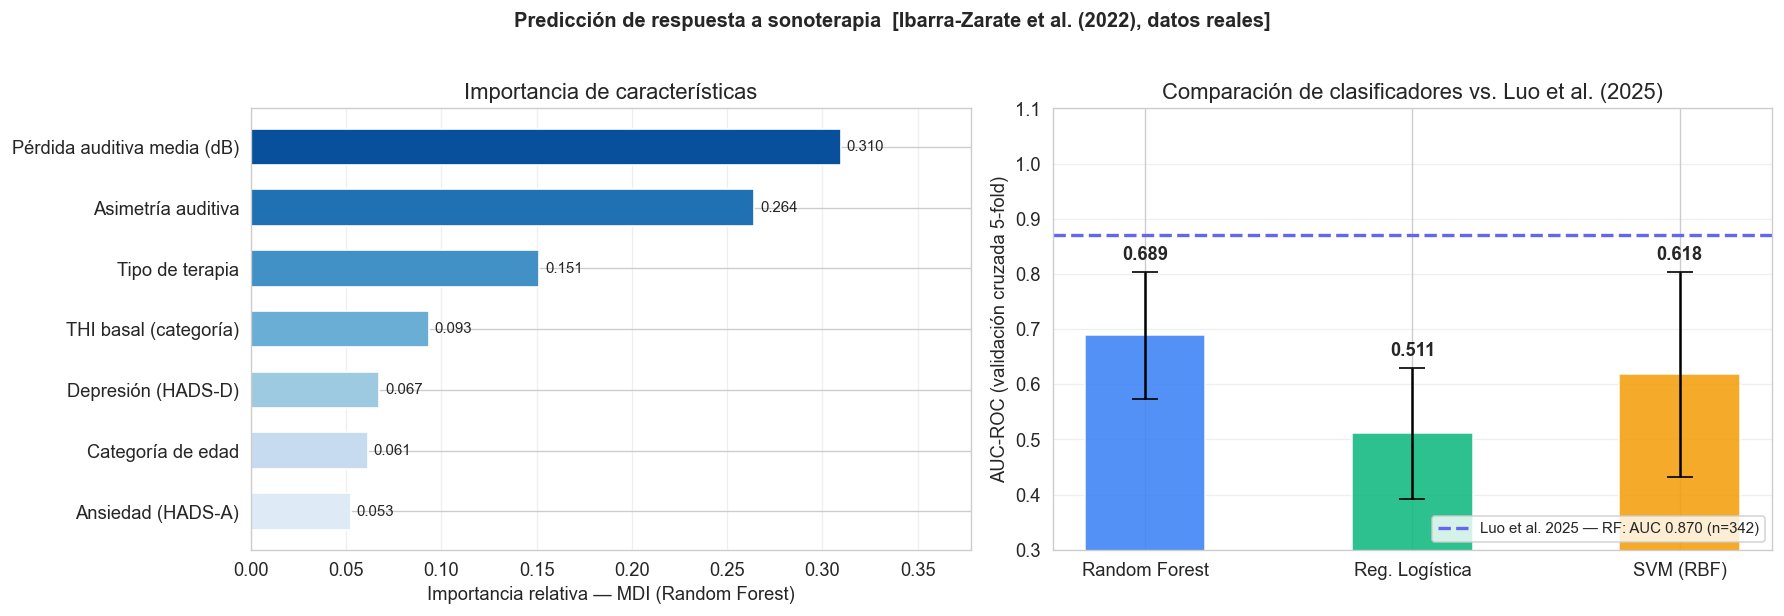

In [51]:
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)

rf_final = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42)
rf_final.fit(X_scaled, y)

labels = {
    "THI_S2": "THI basal (categoría)", "HADS_A": "Ansiedad (HADS-A)",
    "HADS_D": "Depresión (HADS-D)", "HL_avg": "Pérdida auditiva media (dB)",
    "HL_asym": "Asimetría auditiva", "therapy_group": "Tipo de terapia",
    "age_cat": "Categoría de edad",
}
importance = pd.Series(rf_final.feature_importances_, index=features).sort_values()
importance.index = [labels[c] for c in importance.index]

fig, plots = plt.subplots(1, 2, figsize=(15, 5))

# importancia de features (MDI)
colors = sns.color_palette("Blues", len(importance))
bars = plots[0].barh(importance.index, importance.values, color=colors, edgecolor="white", height=0.6)
for bar in bars:
    plots[0].text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                  f"{bar.get_width():.3f}", va="center", fontsize=9)
plots[0].set_xlabel("Importancia relativa — MDI (Random Forest)")
plots[0].set_title("Importancia de características")
plots[0].set_xlim(0, importance.max() * 1.22)
plots[0].grid(True, alpha=0.3, axis="x")

# comparación de modelos
names = list(results.keys())
means = [results[n].mean() for n in names]
stds  = [results[n].std()  for n in names]

bars = plots[1].bar(names, means, yerr=stds, capsize=8,
                    color=["#3B82F6", "#10B981", "#F59E0B"], edgecolor="white", alpha=0.88, width=0.45)
plots[1].axhline(0.870, color="#6366F1", ls="--", lw=2, label="Luo et al. 2025 — RF: AUC 0.870 (n=342)")
for bar, m, s in zip(bars, means, stds):
    plots[1].text(bar.get_x() + bar.get_width()/2, m + s + 0.015,
                  f"{m:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
plots[1].set_ylabel("AUC-ROC (validación cruzada 5-fold)")
plots[1].set_title("Comparación de clasificadores vs. Luo et al. (2025)")
plots[1].set_ylim(0.3, 1.10)
plots[1].legend(fontsize=9, loc="lower right")
plots[1].grid(True, alpha=0.3, axis="y")

plt.suptitle(f"Predicción de respuesta a sonoterapia  [{data_source}]", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 2.6 Análisis de la distribución de cambio en THI por grupo

Una ventaja del dataset de Mendeley respecto al de Luo et al. es que incluye datos longitudinales por grupo terapéutico. Este gráfico permite visualizar si hay diferencias en la magnitud de mejora del THI entre los cinco tipos de terapia, lo que es directamente relevante para decidir qué tipo de sonido ofrecer en la app.

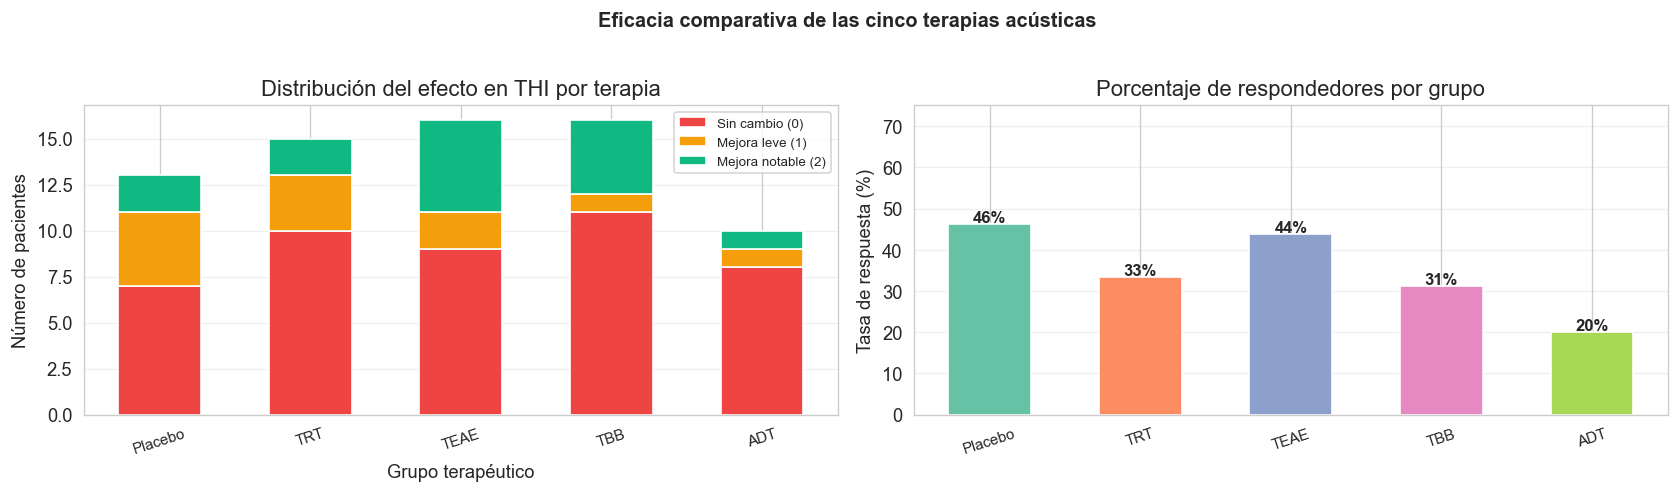


Tasa de respuesta por grupo:
  Placebo (música)                       46.2 %
  TRT (Tinnitus Retraining)              33.3 %
  TEAE (Enriquecimiento Acústico)        43.8 %
  TBB (Binaural Beats)                   31.2 %
  ADT (Discriminación Auditiva)          20.0 %


In [52]:
fig, plots = plt.subplots(1, 2, figsize=(14, 4))

# distribución de THI_effect por grupo — barras apiladas (más honesto que violin para datos ordinales)
df_count = (df_all.dropna(subset=["THI_effect"])
                  .groupby(["therapy_group", "THI_effect"])
                  .size()
                  .reset_index(name="n"))

effect_colors = {0.0: "#EF4444", 1.0: "#F59E0B", 2.0: "#10B981"}
effect_labels = {0.0: "Sin cambio (0)", 1.0: "Mejora leve (1)", 2.0: "Mejora notable (2)"}
group_labels  = [therapy_groups[i].split("(")[0].strip() for i in sorted(therapy_groups.keys())]
bottom_vals   = {g: 0 for g in sorted(therapy_groups.keys())}

for val in [0.0, 1.0, 2.0]:
    subset  = df_count[df_count["THI_effect"] == val].set_index("therapy_group")
    heights = [subset.loc[g, "n"] if g in subset.index else 0 for g in sorted(therapy_groups.keys())]
    plots[0].bar(group_labels, heights, bottom=[bottom_vals[g] for g in sorted(therapy_groups.keys())],
                 color=effect_colors[val], label=effect_labels[val], edgecolor="white", width=0.55)
    for i, g in enumerate(sorted(therapy_groups.keys())):
        bottom_vals[g] += heights[i]

plots[0].set_xlabel("Grupo terapéutico")
plots[0].set_ylabel("Número de pacientes")
plots[0].set_title("Distribución del efecto en THI por terapia")
plots[0].legend(fontsize=8, loc="upper right")
plots[0].tick_params(axis='x', rotation=18, labelsize=9)
plots[0].grid(True, alpha=0.3, axis="y")

# tasa de respuesta por grupo
resp_by_group = df.groupby("therapy_group")["responder"].mean() * 100
bars = plots[1].bar([therapy_groups[i].split("(")[0].strip() for i in resp_by_group.index],
                    resp_by_group.values,
                    color=sns.color_palette("Set2", 5), edgecolor="white", width=0.55)
for bar, val in zip(bars, resp_by_group.values):
    plots[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                  f"{val:.0f}%", ha="center", fontsize=10, fontweight="bold")
plots[1].set_ylabel("Tasa de respuesta (%)")
plots[1].set_title("Porcentaje de respondedores por grupo")
plots[1].set_ylim(0, 75)
plots[1].tick_params(axis='x', rotation=18, labelsize=9)
plots[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Eficacia comparativa de las cinco terapias acústicas", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nTasa de respuesta por grupo:")
for i, rate in resp_by_group.items():
    print(f"  {therapy_groups[i]:<38} {rate:.1f} %")

## 3. Discusión de resultados
El artículo de Luo et al. (2025) muestra que la predicción de respuesta a la sonoterapia es factible utilizando variables clínicas y psicométricas de rutina. Su principal contribución es demostrar que la respuesta terapéutica puede modelarse antes de iniciar el tratamiento, lo que abre la puerta a herramientas de apoyo a la decisión clínica y a sistemas de terapia personalizada.

En mi implementación, el uso del dataset de Mendeley permite reproducir el esquema general del problema, aunque no de forma idéntica. La diferencia entre ambos escenarios es esperable por varias razones:

- el tamaño muestral es más reducido;

- las variables disponibles son distintas;

- la definición de la variable objetivo no coincide exactamente;

- y el conjunto de datos tiene una estructura experimental diferente.

Por tanto, más que una reproducción literal del artículo, este trabajo debe entenderse como una aproximación metodológica inspirada en él.

La comparación entre grupos terapéuticos también resulta interesante, ya que sugiere que no todas las terapias acústicas producen el mismo patrón de respuesta en la muestra analizada. Esto refuerza la utilidad de estudiar modelos que integren el perfil clínico del paciente con el tipo de intervención recibida.

## 4. Conclusión

Este trabajo muestra cómo un problema clínico real puede transformarse en un pipeline completo de machine learning en Python. A partir de datos clínicos y psicométricos, es posible construir un flujo de trabajo que incluya exploración, limpieza, ingeniería de características, comparación de modelos e interpretación de resultados.

¿Qué he aprendido? Que la parte más importante de un proyecto de ML no es elegir el algoritmo, sino construir bien el pipeline: definir correctamente la variable objetivo, tratar los valores ausentes, escalar dentro del CV para evitar data leakage y entender qué mide cada variable antes de usarla. Este trabajo me ha enseñado que el conocimiento del dominio clínico y el código de Python son igualmente necesarios — uno sin el otro no produce resultados fiables. En el contexto de MyTinnitusMask, esta experiencia resulta especialmente valiosa porque ayuda a traducir una necesidad clínica concreta en una solución computacional orientada a la personalización terapéutica.

## Declaración de Uso de IA

Se han utilizado herramientas de inteligencia artificial generativa para apoyar la búsqueda y selección de artículos científicos relevantes, ayudar con el formato de referencias en estilo APA 7ª edición y revisar la redacción en español. Todo el código Python ha sido escrito y verificado por la autora.

## Referencias

Haider, H. F., Hoare, D. J., Costa, R. F. P., Potgieter, I., Bhatt, J. M., Bhatt, J., Baguley, D. M., & Cederroth, C. R. (2022). Global prevalence and incidence of tinnitus: A systematic review and meta-analysis. JAMA Neurology, 79(9), 888–900. https://doi.org/10.1001/jamaneurol.2022.2189

Ibarra-Zarate, D. I., Alonso-Valerdi, L. M., Cuevas-Romero, A. R., & Intriago-Campos, L. A. (2022). Acoustic therapies for tinnitus treatment: An EEG database. Mendeley Data, Version 2. https://doi.org/10.17632/kj443jc4yc.2

Luo, G., Lin, Q., Lin, C., & Wu, H. (2025). An innovative predictive model for assessing tinnitus sound therapy outcomes: integrating audiological and psychometric variables. Frontiers in Neurology, 16, 1727373. https://doi.org/10.3389/fneur.2025.1727373